# Palace CPW Simulation — Wave Ports

[Palace](https://awslabs.github.io/palace/) is an open-source 3D electromagnetic simulator supporting eigenmode, driven (S-parameter), and electrostatic simulations. This notebook demonstrates using the `gsim.palace` API to run a driven simulation on a CPW (coplanar waveguide) structure with **wave ports**.

**Requirements:**

- IHP PDK: `uv pip install ihp-gdsfactory`
- [GDSFactory+](https://gdsfactory.com) account for cloud simulation

### Define GSG electrode

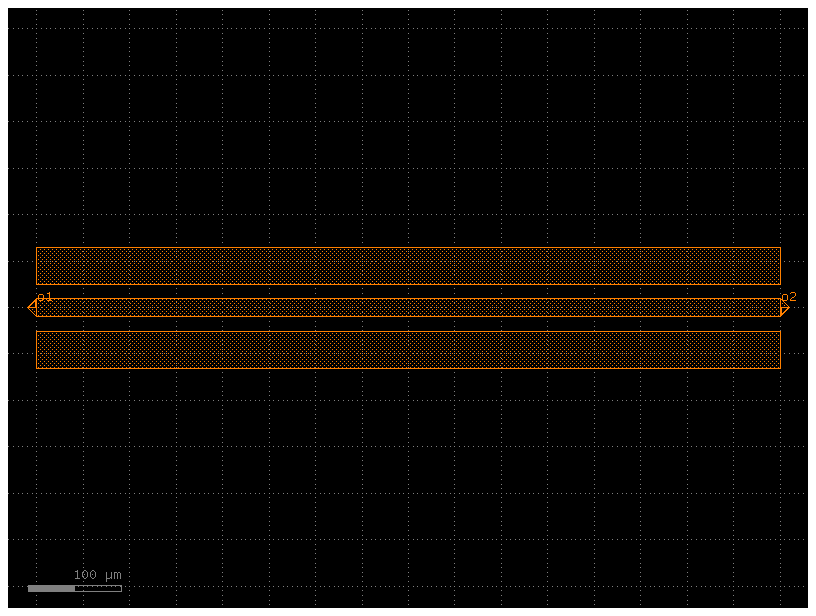

In [1]:
import gdsfactory as gf
from ihp import LAYER, PDK

PDK.activate()


@gf.cell
def gsg_electrode(
    length: float = 800,
    s_width: float = 20,
    g_width: float = 40,
    gap_width: float = 15,
    layer=LAYER.TopMetal2drawing,
) -> gf.Component:
    """
    Create a GSG (Ground-Signal-Ground) electrode.

    Args:
        length: horizontal length of the electrodes
        s_width: width of the signal (center) electrode
        g_width: width of the ground electrodes
        gap_width: gap between signal and ground electrodes
        layer: layer for the metal
    """
    c = gf.Component()

    r1 = c << gf.c.rectangle((length, g_width), centered=True, layer=layer)
    r1.move((0, (g_width + s_width) / 2 + gap_width))

    _r2 = c << gf.c.rectangle((length, s_width), centered=True, layer=layer)

    r3 = c << gf.c.rectangle((length, g_width), centered=True, layer=layer)
    r3.move((0, -(g_width + s_width) / 2 - gap_width))

    c.add_port(
        name="o1",
        center=(-length / 2, 0),
        width=s_width,
        orientation=180,
        port_type="electrical",
        layer=layer,
    )

    c.add_port(
        name="o2",
        center=(length / 2, 0),
        width=s_width,
        orientation=0,
        port_type="electrical",
        layer=layer,
    )

    return c


c = gsg_electrode()
cc = c.copy()
cc.draw_ports()
cc

### Configure simulation

In [ ]:
from gsim.common.stack import get_stack
from gsim.palace import DrivenSim

sim = DrivenSim()
sim.set_output_dir("./palace-sim-cpw-waveport")
sim.set_geometry(c)

stack = get_stack()  # auto-detects active PDK
sim.set_stack(stack)
sim.set_airbox(margin_x=0.0, margin_y=50, z_above=100.0, z_below=100.0)

# Wave ports — max_size fills the full domain boundary
sim.add_wave_port("o1", layer="topmetal2", max_size=True, mode=1, excited=True)
sim.add_wave_port("o2", layer="topmetal2", max_size=True, mode=1, excited=False)

sim.set_driven(fmin=1e9, fmax=100e9, num_points=300)

print(sim.validate_config())

Validation: PASSED


### Generate mesh

In [ ]:
sim.mesh(preset="default", refined_mesh_size=2.0, max_mesh_size=40.0, fmax=150e9)

Mesh Summary
Dimensions: 800.0 x 130.0 x 217.9 µm
Nodes:      31,782
Elements:   225,787
Tetrahedra: 157,469
Edge length: 1.16 - 76.42 µm
Quality:    0.643 (min: 0.000)
SICN:       0.695 (all valid)
----------------------------------------
Volumes (3):
  - si [1]
  - sin [2]
  - air [3]
Surfaces (10):
  - topmetal2_xy [4]
  - topmetal2_z [5]
  - P1 [6]
  - P2 [7]
  - si__None [8]
  - si__sin [9]
  - air__si [10]
  - sin__None [11]
  - air__sin [12]
  - air__None [13]
----------------------------------------
Mesh:   palace-sim-cpw-waveport/palace.msh

In [5]:
sim.plot_mesh(
    style="solid",
    transparent_groups=["air__None", "SiO2__None", "SiO2__passive", "air__passive"],
    interactive=True,
)

Widget(value='<iframe src="http://localhost:39883/index.html?ui=P_0x7aee86368440_0&reconnect=auto" class="pyvi…

### Run simulation

In [6]:
sim.write_config()
results = sim.run_local()

Running Palace simulation in palace-sim-cpw-waveport via Apptainer
Command: apptainer run /home/martin/Desktop/palace/Palace.sif -np 32 config.json
Processes: 32
>> /usr/lib64/mpich/bin/mpirun -n 32 /opt/palace/bin/palace-x86_64.bin config.json
_____________     _______
_____   __   \____ __   /____ ____________
____   /_/  /  __ ` /  /  __ ` /  ___/  _ \
___   _____/  /_/  /  /  /_/  /  /__/  ___/
  /__/     \___,__/__/\___,__/\_____\_____/
--> Warning!
Output folder is not empty; program will overwrite content! (output/palace)
Git changeset ID: v0.14.0-305-g51d61b03
Running with 32 MPI processes, 1 OpenMP thread
Device configuration: omp,cpu
Memory configuration: host-std
libCEED backend: /cpu/self/xsmm/blocked
Added 12868 duplicate vertices for interior boundaries in the mesh
Added 24140 duplicate boundary elements for interior boundaries in the mesh
Finished partitioning mesh into 32 subdomains
Characteristic length and time scales:
 L₀ = 8.000e-04 m, t₀ = 2.669e-03 ns
Mesh curvatu

### Plot S-parameters

In [7]:
results.plot_interactive()

Port mapping: Port 1: p1, Port 2: p2


In [8]:
results.plot_interactive(phase=True)

Port mapping: Port 1: p1, Port 2: p2
